Processing .: 0it [00:00, ?it/s]
Processing VASC: 100%|██████████| 202/202 [00:31<00:00,  6.40it/s]


✅ Total saved in C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\train: 20172


Processing .: 0it [00:00, ?it/s]
Processing VASC: 100%|██████████| 26/26 [00:02<00:00,  8.69it/s]


✅ Total saved in C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\test: 2127


Processing .: 0it [00:00, ?it/s]
Processing VASC: 100%|██████████| 25/25 [00:03<00:00,  7.06it/s]


✅ Total saved in C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\val: 3032


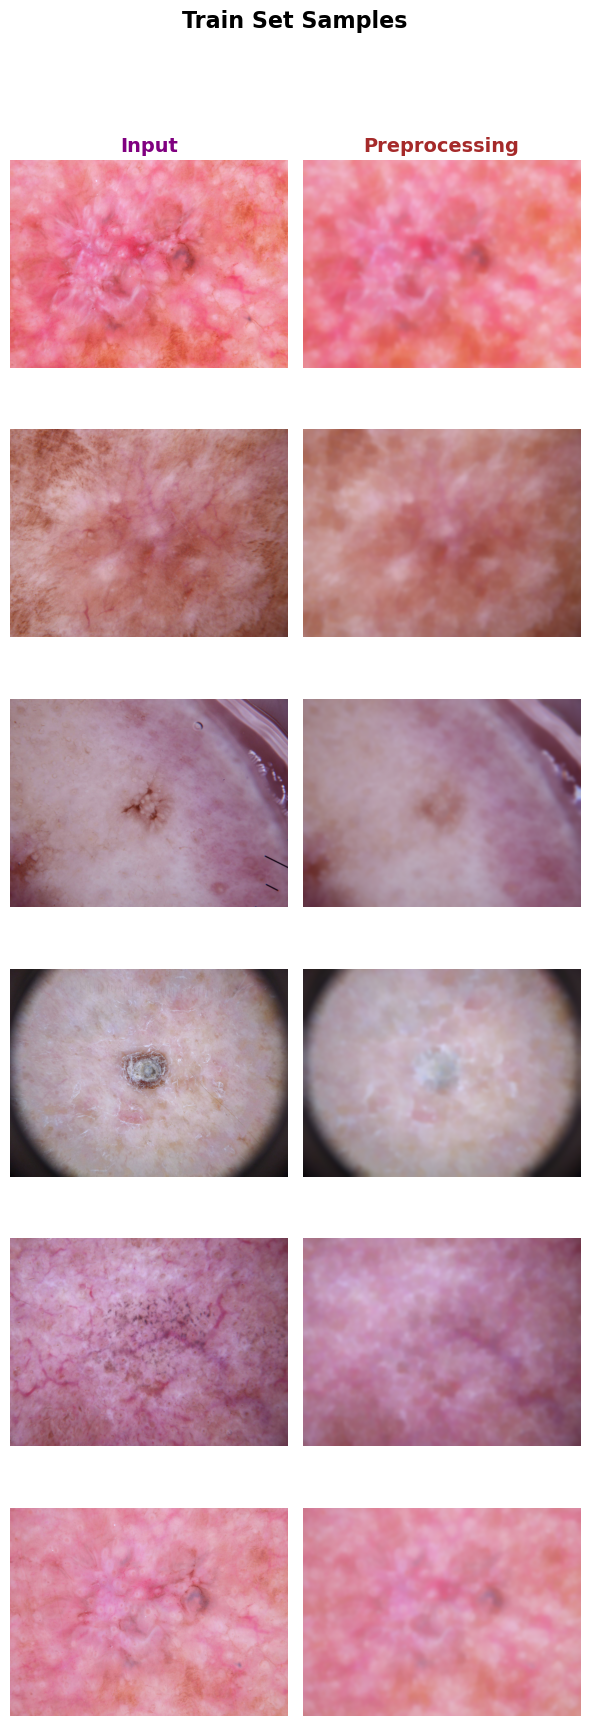

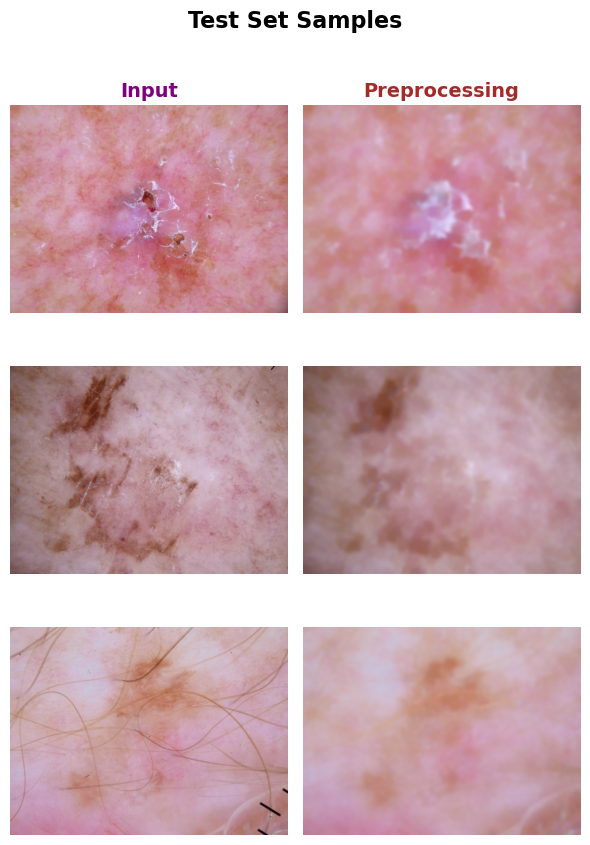

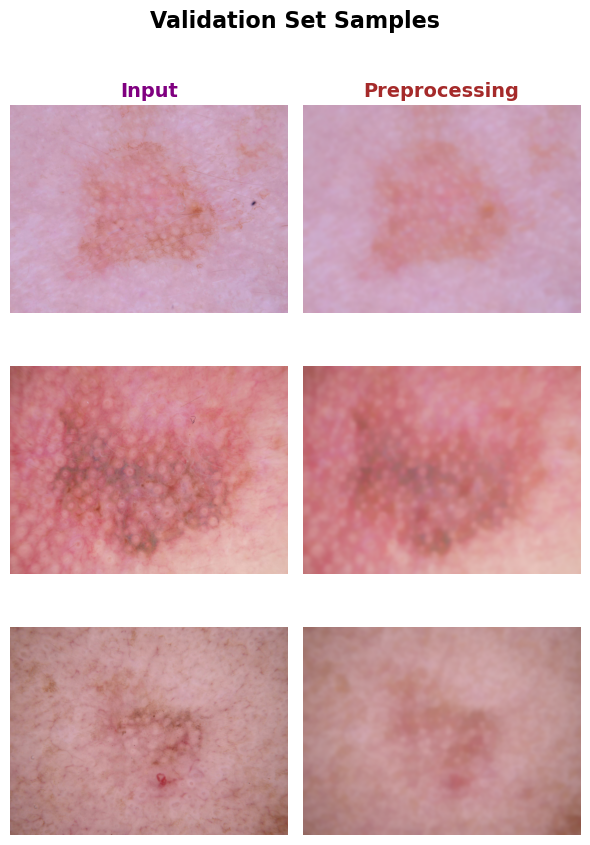

In [1]:
import cv2
import os
import numpy as np
from scipy.ndimage import uniform_filter
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------------------
# Hair Removal
# ---------------------------
def remove_hairs(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)

# ---------------------------
# Bubble Removal
# ---------------------------
def remove_bubbles(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY)  # detect bright spots
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    return cv2.inpaint(img, thresh, 3, cv2.INPAINT_TELEA)

# ---------------------------
# Window-Aware Guided Filter (WGIF)
# ---------------------------
def window_aware_guided_filter(I, p, r=7, eps=1e-6, omega=0.2):
    """
    Lesion-preserve filtering:
      - Smooths skin
      - Keeps lesion edges sharp
      - Avoids brightening dark regions
    """
    I = I.astype(np.float32)
    p = p.astype(np.float32)

    mean_I = uniform_filter(I, r)
    mean_p = uniform_filter(p, r)
    corr_I = uniform_filter(I * I, r)
    corr_Ip = uniform_filter(I * p, r)

    var_I = corr_I - mean_I * mean_I
    cov_Ip = corr_Ip - mean_I * mean_p

    window_contrast = np.sqrt(np.maximum(var_I, 0))
    k = cov_Ip / (var_I + eps)
    weight = np.exp(- (window_contrast ** 2) / (2 * (omega ** 2)))
    k *= weight

    b = mean_p - k * mean_I
    mean_k = uniform_filter(k, r)
    mean_b = uniform_filter(b, r)

    q = mean_k * I + mean_b
    return np.clip(q, 0, 255).astype(np.uint8)

# ---------------------------
# Preprocess Single Image
# ---------------------------
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read {img_path}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 1: Hair removal
    img = remove_hairs(img)

    # Step 2: Bubble removal
    img = remove_bubbles(img)

    # Step 3: WGIF per channel (keeps lesions dark)
    filtered_channels = [window_aware_guided_filter(c, c, r=7, omega=0.3) for c in cv2.split(img)]
    processed_img = cv2.merge(filtered_channels)

    return processed_img

# ---------------------------
# Process Folder (with subfolders)
# ---------------------------
def process_folder(input_folder, output_folder, num_samples=6):
    sample_images = []
    count = 0

    for root, dirs, files in os.walk(input_folder):
        rel_path = os.path.relpath(root, input_folder)
        save_dir = os.path.join(output_folder, rel_path)
        os.makedirs(save_dir, exist_ok=True)

        for filename in tqdm(files, desc=f"Processing {rel_path}"):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                input_path = os.path.join(root, filename)
                output_path = os.path.join(save_dir, filename)

                processed_img = preprocess_image(input_path)
                if processed_img is None:
                    continue

                processed_img_bgr = cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR)
                cv2.imwrite(output_path, processed_img_bgr)
                count += 1

                if len(sample_images) < num_samples:
                    orig = cv2.cvtColor(cv2.imread(input_path), cv2.COLOR_BGR2RGB)
                    sample_images.append((orig, processed_img))

    print(f"✅ Total saved in {output_folder}: {count}")
    return sample_images

# ---------------------------
# Side-by-side Comparison Grid
# ---------------------------
def show_comparison_grid(samples, title="Input vs Preprocessing"):
    if not samples:
        print("⚠️ No samples to display")
        return

    n = len(samples)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    if n == 1:
        axes = np.array([axes])

    axes[0,0].set_title("Input", fontsize=14, fontweight="bold", color="purple")
    axes[0,1].set_title("Preprocessing", fontsize=14, fontweight="bold", color="brown")

    for i, (orig, proc) in enumerate(samples):
        axes[i,0].imshow(orig); axes[i,0].axis("off")
        axes[i,1].imshow(proc); axes[i,1].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# ---------------------------
# Paths
# ---------------------------
train_input = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Sorted_Images\train"
test_input  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Sorted_Images\test"
val_input   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Sorted_Images\val"

train_output = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\train"
test_output  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\test"
val_output   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed1\val"

# ---------------------------
# Run
# ---------------------------
train_samples = process_folder(train_input, train_output, num_samples=6)
test_samples  = process_folder(test_input,  test_output,  num_samples=3)
val_samples   = process_folder(val_input,   val_output,   num_samples=3)

show_comparison_grid(train_samples, "Train Set Samples")
show_comparison_grid(test_samples,  "Test Set Samples")
show_comparison_grid(val_samples,   "Validation Set Samples")


In [ ]:
# --- Fast ARKFCM (PyTorch, GPU-ready) --- (SEGMENTATION)
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from concurrent.futures import ProcessPoolExecutor

# ---------------------------
# Core: ARKFCM on one image (vectorized, GPU-ready)
# ---------------------------
@torch.no_grad()
def arkfcm_segmentation_torch(
    img_gray_uint8: np.ndarray,
    n_clusters: int = 2,
    m: float = 2.0,
    alpha: float = 2.0,
    window_size: int = 3,
    max_iter: int = 20,
    tol: float = 1e-4,
    downscale_max_side: int = 512,
    device: str | torch.device = None,
) -> np.ndarray:
    assert img_gray_uint8.ndim == 2, "Provide a single-channel (grayscale) image."
    H0, W0 = img_gray_uint8.shape

    # Auto device
    device = torch.device(device) if device is not None else (
        torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    )

    # Optional downscale for speed
    H, W = H0, W0
    scale = 1.0
    max_side = max(H0, W0)
    if max_side > downscale_max_side:
        scale = downscale_max_side / max_side
        H = max(1, int(round(H0 * scale)))
        W = max(1, int(round(W0 * scale)))
        img_small = cv2.resize(img_gray_uint8, (W, H), interpolation=cv2.INTER_AREA)
    else:
        img_small = img_gray_uint8

    # To torch [0,1], shape (1,1,H,W)
    I = torch.from_numpy(img_small.astype(np.float32) / 255.0).to(device)
    I4 = I.view(1, 1, H, W)

    # Fast local mean/variance with box filter (reflect padding)
    pad = window_size // 2
    kernel = torch.ones((1, 1, window_size, window_size), device=device) / (window_size * window_size)
    I_pad = F.pad(I4, (pad, pad, pad, pad), mode="reflect")
    mean_local = F.conv2d(I_pad, kernel)
    mean2_local = F.conv2d(I_pad * I_pad, kernel)
    var_local = torch.clamp(mean2_local - mean_local * mean_local, min=0.0)

    # Flatten for vectorized ARKFCM math
    y = I4.flatten().unsqueeze(1)                    # (N,1)
    mean_flat = mean_local.flatten()                 # (N,)
    var_flat = var_local.flatten()                   # (N,)

    N = y.shape[0]
    C = n_clusters

    # Initialize memberships (Dirichlet-like)
    U = torch.rand((N, C), device=device)
    U = U / (U.sum(dim=1, keepdim=True) + 1e-12)

    p = 1.0 / (m - 1.0)

    for _ in range(max_iter):
        U_old = U

        # Update centers: (U^m)^T y / sum(U^m)
        Um = (U ** m)                                # (N,C)
        denom_c = Um.sum(dim=0, keepdim=True)        # (1,C)
        centers = (Um.t() @ y) / (denom_c.t() + 1e-12)   # (C,1)

        # phi per pixel (vectorized)
        ya = y.squeeze(1)                            # (N,)
        phi = torch.where(
            ya < mean_flat, 2.0 + var_flat,
            torch.where(ya > mean_flat, 2.0 - var_flat, torch.zeros_like(var_flat))
        )                                            # (N,)

        # Gaussian RBF distances to centers (vectorized)
        diff2 = (y - centers.t()) ** 2               # (N,C)
        H_ab = torch.exp(-diff2 / (alpha ** 2 + 1e-12))
        one_minus_H = (1.0 - H_ab)
        dist = (1.0 + phi.unsqueeze(1)) * one_minus_H + 1e-12  # (N,C)

        # Update U using pairwise ratio trick
        dist_i = dist.unsqueeze(2)                   # (N,C,1)
        dist_j = dist.unsqueeze(1)                   # (N,1,C)
        ratios = (dist_i / dist_j).pow(p)            # (N,C,C)
        denom = ratios.sum(dim=2)                    # (N,C)
        U = 1.0 / (denom + 1e-12)

        # Convergence check
        if torch.norm(U - U_old).item() < tol:
            break

    # Label = cluster with max membership
    labels = U.argmax(dim=1).view(H, W)              # (H,W)

    # Choose lesion cluster as the darker center
    centers_1d = centers.view(-1)                    # (C,)
    lesion_cluster = int(torch.argmin(centers_1d).item())
    mask_small = (labels == lesion_cluster).to(torch.uint8) * 255  # (H,W)

    # Upscale back to original size
    if scale != 1.0:
        mask = cv2.resize(mask_small.detach().cpu().numpy(), (W0, H0), interpolation=cv2.INTER_NEAREST)
    else:
        mask = mask_small.detach().cpu().numpy()

    return mask

# ---------------------------
# I/O helpers
# ---------------------------
def process_image_torch(img_path: str, out_path: str, **kwargs):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Could not read: {img_path}")
        return
    mask = arkfcm_segmentation_torch(img, **kwargs)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)  # ✅ ensure subfolder exists
    cv2.imwrite(out_path, mask)
    print(f"✅ Saved: {out_path}")

def collect_images(input_dir: str, valid_exts=('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
    paths = []
    for root, _, files in os.walk(input_dir):
        for f in files:
            if f.lower().endswith(valid_exts):
                paths.append(os.path.join(root, f))
    return paths

# ---------------------------
# Folder processing (preserves subfolder structure)
# ---------------------------
def process_folder_smart(input_dir: str, output_dir: str, workers: int = 0, **seg_kwargs):
    img_paths = collect_images(input_dir)
    if not img_paths:
        print(f"⚠️ No images found in {input_dir}")
        return

    use_cuda = torch.cuda.is_available()
    if use_cuda:
        for p in img_paths:
            rel = os.path.relpath(p, input_dir)  # ✅ keeps class subfolder
            out = os.path.join(output_dir, os.path.splitext(rel)[0] + ".png")
            process_image_torch(p, out, **seg_kwargs, device="cuda")
    else:
        if workers and workers > 0:
            with ProcessPoolExecutor(max_workers=workers) as ex:
                futures = []
                for p in img_paths:
                    rel = os.path.relpath(p, input_dir)
                    out = os.path.join(output_dir, os.path.splitext(rel)[0] + ".png")
                    futures.append(ex.submit(process_image_torch, p, out, **seg_kwargs, device="cpu"))
                for f in futures:
                    _ = f.result()
        else:
            for p in img_paths:
                rel = os.path.relpath(p, input_dir)
                out = os.path.join(output_dir, os.path.splitext(rel)[0] + ".png")
                process_image_torch(p, out, **seg_kwargs, device="cpu")

# ---------------------------
# Example: set your folders and run
# ---------------------------
if __name__ == "__main__":
    train_input = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed\train"
    test_input  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed\test"
    val_input   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\preprocessed\val"

    train_output = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\segmented\train"
    test_output  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\segmented\test"
    val_output   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\segmented\val"

    # Tunables for speed/quality
    common_kwargs = dict(
        n_clusters=2,
        m=2.0,
        alpha=2.0,
        window_size=5,
        max_iter=15,
        tol=1e-4,
        downscale_max_side=512
    )

    process_folder_smart(train_input, train_output, workers=0, **common_kwargs)
    process_folder_smart(test_input,  test_output,  workers=0, **common_kwargs)
    process_folder_smart(val_input,   val_output,   workers=0, **common_kwargs)


In [ ]:

# ✅ FEATURE EXTRACTION
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

# ✅ SkinWiseNet Feature Extractor (up to GAP)
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class SkinWiseNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(SkinWiseNetFeatureExtractor, self).__init__()
        self.stage1 = nn.Sequential(
            ConvBNReLU(3, 32, stride=1),
            ConvBNReLU(32, 32, stride=1),
            ConvBNReLU(32, 32, stride=2)
        )
        self.stage2 = nn.Sequential(
            ConvBNReLU(32, 64, stride=1),
            ConvBNReLU(64, 64, stride=2)
        )
        self.stage3 = nn.Sequential(
            ConvBNReLU(64, 128, stride=1),
            ConvBNReLU(128, 128, stride=2)
        )
        self.stage4 = nn.Sequential(
            ConvBNReLU(128, 256, stride=1),
            ConvBNReLU(256, 256, stride=2)
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        return torch.flatten(x, 1)  # [batch, 256]


# ✅ Dataset paths
datasets_paths = {
    "train": r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\mulsegmented\train",
    "val":  r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\mulsegmented\val",
    "test":  r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\mulsegmented\test"
}

# ✅ Output root
output_root = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Feature extraction234"
os.makedirs(output_root, exist_ok=True)

# ✅ Fixed class order
fixed_classes = ["AK", "BCC", "BKL", "DF", "MEL", "NV","SCC","VASC"]
class_mapping = {i: cls for i, cls in enumerate(fixed_classes)}

# ✅ Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ✅ Feature Extraction Function
def extract_features(data_dir, output_file, model, device):
    dataset = datasets.ImageFolder(data_dir, transform=transform)

    # 🧩 Ensure dataset follows the fixed class order
    dataset.classes = fixed_classes
    dataset.class_to_idx = {cls: i for i, cls in enumerate(fixed_classes)}

    print(f"\n📂 Loaded {len(dataset)} images from {data_dir}")
    print(f"📝 Using fixed classes: {dataset.classes}")

    dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

    all_features, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            features = model(imgs)  # [batch, 256]
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    if len(all_features) == 0:
        print(f"⚠️ No features extracted from {data_dir} (check if images exist and are inside class subfolders).")
        return None

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    np.savez(output_file, features=all_features, labels=all_labels, classes=fixed_classes)
    print(f"✅ Saved features to {output_file} | Features shape: {all_features.shape}, Labels shape: {all_labels.shape}")


# ✅ Main
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Using device: {device}")

    model = SkinWiseNetFeatureExtractor().to(device)
    model.eval()

    for name, path in datasets_paths.items():
        output_file = os.path.join(output_root, f"{name}_features.npz")
        extract_features(path, output_file, model, device)

    # ✅ Save fixed class mapping
    mapping_file = os.path.join(output_root, "class_mapping.json")
    with open(mapping_file, "w") as f:
        json.dump(class_mapping, f, indent=4)
    print(f"\n📌 Class mapping saved to {mapping_file}")
    print(class_mapping)


In [ ]:
# JACKAL SEARCH OPTIMIZATION
import os
import random
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import time

# =====================================================
# USER CONFIGURATION
# =====================================================

# Optional: enable GPU with safe memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected, using CPU mode.")

# Input feature CSV paths
TRAIN_CSV = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Feature extraction234\train_features.csv"
VAL_CSV   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Feature extraction234\val_features.csv"
TEST_CSV  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\Feature extraction234\test_features.csv"
# Output directories
OUTPUT_TRAIN_DIR = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\train"
OUTPUT_VAL_DIR   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\val"
OUTPUT_TEST_DIR  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\test"

# Create output folders if they don’t exist
os.makedirs(OUTPUT_TRAIN_DIR, exist_ok=True)
os.makedirs(OUTPUT_VAL_DIR, exist_ok=True)
os.makedirs(OUTPUT_TEST_DIR, exist_ok=True)

# =====================================================
# JSO + TRAINING CONFIG
# =====================================================
POP_SIZE = 10        # reduced for stability
MAX_ITER = 50        # fewer iterations for safe training
TRIAL_EPOCHS = 100    # fewer epochs per classifier
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# =====================================================
# LOAD FEATURE DATASETS
# =====================================================
def load_feature_csv(path):
    df = pd.read_csv(path)
    if df.shape[1] < 2:
        raise ValueError(f"CSV {path} has insufficient columns.")
    X = df.iloc[:, :-1].values.astype(np.float32)
    y = df.iloc[:, -1].values
    return X, y, df.columns[:-1].tolist(), df.columns[-1]

X_train, y_train_raw, feature_names, label_name = load_feature_csv(TRAIN_CSV)
X_val, y_val_raw, _, _ = load_feature_csv(VAL_CSV)
X_test, y_test_raw, _, _ = load_feature_csv(TEST_CSV)

# Encode labels consistently
le = LabelEncoder()
le.fit(np.concatenate([y_train_raw, y_val_raw, y_test_raw]))
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
y_test = le.transform(y_test_raw)
NUM_CLASSES = len(le.classes_)
NUM_FEATURES = X_train.shape[1]

print(f"Features: {NUM_FEATURES}, Classes: {NUM_CLASSES}")

# =====================================================
# BUILD CLASSIFIER MODEL
# =====================================================
def build_classifier(input_dim, dense_units=128, dropout_rate=0.4):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(dense_units, activation="relu")(inp)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# =====================================================
# EVALUATE FEATURE SUBSET
# =====================================================
def evaluate_subset(mask, X_tr, y_tr, X_va, y_va):
    """Evaluate subset using validation accuracy"""
    if mask.sum() == 0:
        return 10.0, 0.0, 10.0

    X_tr_sel = X_tr[:, mask == 1]
    X_va_sel = X_va[:, mask == 1]

    try:
        classes = np.unique(y_tr)
        cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
        class_weights = {int(c): float(w) for c, w in zip(classes, cw)}
    except Exception:
        class_weights = None

    model = build_classifier(X_tr_sel.shape[1])
    es = callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True, verbose=0)
    model.fit(X_tr_sel, y_tr, validation_data=(X_va_sel, y_va),
              epochs=TRIAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
              callbacks=[es], class_weight=class_weights)

    val_loss, val_acc = model.evaluate(X_va_sel, y_va, verbose=0)
    fitness = (1 - val_acc) + 0.1 * val_loss

    # Free memory
    tf.keras.backend.clear_session()
    del model
    gc.collect()

    return fitness, val_acc, val_loss

# =====================================================
#JSO BINARY VARIANT
# =====================================================
def sigmoid(x): return 1 / (1 + np.exp(-x))
def initialize_population(n, dim): return np.random.randn(n, dim)
def to_binary(vec): return (sigmoid(vec) > 0.5).astype(int)

def gjo(X_tr, y_tr, X_va, y_va, pop_size=POP_SIZE, max_iter=MAX_ITER):
    dim = X_tr.shape[1]
    pop = initialize_population(pop_size, dim)
    fitness = np.full(pop_size, np.inf)
    accs = np.zeros(pop_size)

    print("Evaluating initial population...")
    for i in range(pop_size):
        mask = to_binary(pop[i])
        f, a, _ = evaluate_subset(mask, X_tr, y_tr, X_va, y_va)
        fitness[i] = f
        accs[i] = a
        print(f"Init {i:02d}: selected={mask.sum()} acc={a:.4f} fit={f:.4f}")

    best_idx = np.argsort(fitness)
    male, female = best_idx[0], best_idx[1]
    best_hist = []

    for t in range(1, max_iter + 1):
        a = 2 * (1 - t / max_iter)
        for i in range(pop_size):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            A = 2 * a * r1 - a
            C = 2 * r2
            Dm = np.abs(C * pop[male] - pop[i])
            Df = np.abs(C * pop[female] - pop[i])
            newX = (pop[male] - A * Dm + pop[female] - A * Df) / 2

            if np.random.rand() < 0.1:
                newX += np.random.normal(0, 0.1, size=newX.shape)

            mask_new = to_binary(newX)
            f_new, a_new, _ = evaluate_subset(mask_new, X_tr, y_tr, X_va, y_va)
            if f_new < fitness[i]:
                pop[i] = newX
                fitness[i] = f_new
                accs[i] = a_new

        best_idx = np.argsort(fitness)
        male, female = best_idx[0], best_idx[1]
        best_hist.append((t, fitness[male], accs[male]))
        print(f"[Iter {t:02d}] best_acc={accs[male]:.4f} features={(sigmoid(pop[male])>0.5).sum()}")

    best_mask = to_binary(pop[male])
    return best_mask, best_hist

# =====================================================
# MAIN EXECUTION
# =====================================================
if __name__ == "__main__":
    tic = time.time()
    best_mask, hist = gjo(X_train, y_train, X_val, y_val)
    toc = time.time()

    selected_idx = np.where(best_mask == 1)[0]
    selected_names = [feature_names[i] for i in selected_idx]

    print("\n=== GJO Feature Selection Result ===")
    print("Selected features:", len(selected_names))
    print("Elapsed time: %.1f s" % (toc - tic))

    # --- Save selected feature mask ---
    mask_path = os.path.join(OUTPUT_TEST_DIR, "gjo_selected_features1.csv")
    pd.DataFrame({
        "feature": feature_names,
        "selected": best_mask.astype(int)
    }).to_csv(mask_path, index=False)
    print(f"Saved: {mask_path}")

    # --- Save reduced TRAIN set ---
    Xtr_sel = pd.DataFrame(X_train[:, selected_idx], columns=selected_names)
    Xtr_sel[label_name] = y_train_raw
    train_path = os.path.join(OUTPUT_TRAIN_DIR, "train_selected1.csv")
    Xtr_sel.to_csv(train_path, index=False)
    print(f"Saved: {train_path}")

    # --- Save reduced VAL set ---
    Xva_sel = pd.DataFrame(X_val[:, selected_idx], columns=selected_names)
    Xva_sel[label_name] = y_val_raw
    val_path = os.path.join(OUTPUT_VAL_DIR, "val_selected1.csv")
    Xva_sel.to_csv(val_path, index=False)
    print(f"Saved: {val_path}")

    # --- Save reduced TEST set ---
    Xte_sel = pd.DataFrame(X_test[:, selected_idx], columns=selected_names)
    Xte_sel[label_name] = y_test_raw
    test_path = os.path.join(OUTPUT_TEST_DIR, "test_selected1.csv")
    Xte_sel.to_csv(test_path, index=False)
    print(f"Saved: {test_path}")

    print("\n✅ All output files saved successfully!")


In [ ]:
#CLASSIFICATION

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
from itertools import cycle

# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------
# Dataset Class
# -------------------------
class FeatureDataset(Dataset):
    def __init__(self, csv_file, scaler=None, label_encoder=None, fit_encoder=False, neighbor_mode="noisy"):
        data = pd.read_csv(csv_file)
        X = data.iloc[:, :-1].values.astype(np.float32)
        y_raw = data.iloc[:, -1].values

        if scaler:
            X = scaler.transform(X)

        if label_encoder is None:
            label_encoder = LabelEncoder()

        if fit_encoder:
            y = label_encoder.fit_transform(y_raw)
        else:
            y = label_encoder.transform(y_raw)

        self.X = X
        self.y = y
        self.label_encoder = label_encoder
        self.neighbor_mode = neighbor_mode

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.neighbor_mode == "noisy":
            noise_scale = 0.01
            neighbors_up = np.expand_dims(x + np.random.normal(0, noise_scale, size=x.shape).astype(np.float32), axis=0)
            neighbors_down = np.expand_dims(x + np.random.normal(0, noise_scale, size=x.shape).astype(np.float32), axis=0)
        elif self.neighbor_mode == "random":
            rand_idx1 = np.random.choice(len(self.X))
            rand_idx2 = np.random.choice(len(self.X))
            neighbors_up = np.expand_dims(self.X[rand_idx1].astype(np.float32), axis=0)
            neighbors_down = np.expand_dims(self.X[rand_idx2].astype(np.float32), axis=0)
        else:
            raise ValueError("neighbor_mode must be 'noisy' or 'random'")

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(neighbors_up, dtype=torch.float32),
            torch.tensor(neighbors_down, dtype=torch.float32),
        )

# -------------------------
# Simplicial Attention Layer
# -------------------------
class SimplicialAttentionLayer(nn.Module):
    def __init__(self, in_features, out_features, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        self.W1 = nn.ModuleList([nn.Linear(in_features, out_features) for _ in range(num_heads)])
        self.W2 = nn.ModuleList([nn.Linear(in_features, out_features) for _ in range(num_heads)])
        self.attn_dropout = nn.Dropout(0.1)

    def forward(self, x, neighbors_up, neighbors_down):
        if neighbors_up.dim() == 2:
            neighbors_up = neighbors_up.unsqueeze(1)
        if neighbors_down.dim() == 2:
            neighbors_down = neighbors_down.unsqueeze(1)

        head_outputs = []
        for h in range(self.num_heads):
            h_up = self.W1[h](neighbors_up)
            h_down = self.W2[h](neighbors_down)
            h_up = torch.mean(h_up, dim=1)
            h_down = torch.mean(h_down, dim=1)
            h_out = F.relu(h_up + h_down)
            head_outputs.append(h_out)
        return torch.cat(head_outputs, dim=-1)

# -------------------------
# CAAN block
# -------------------------
class CAAN(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.translator = nn.Linear(feature_dim, feature_dim)
        self.discriminator = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, src_features, tgt_features):
        fake_tgt = self.translator(src_features)
        disc_real = self.discriminator(tgt_features)
        disc_fake = self.discriminator(fake_tgt.detach())
        return fake_tgt, disc_real, disc_fake

# -------------------------
# Cy-CSAAANets Model
# -------------------------
class CyCSAAANets(nn.Module):
    def __init__(self, input_dim=63, hidden_dim=128, num_classes=2, num_heads=4, dropout=0.5):
        super().__init__()
        self.san1 = SimplicialAttentionLayer(input_dim, hidden_dim, num_heads=num_heads)
        self.san2 = SimplicialAttentionLayer(hidden_dim * num_heads, hidden_dim, num_heads=num_heads)
        self.san3 = SimplicialAttentionLayer(hidden_dim * num_heads, hidden_dim, num_heads=num_heads)
        self.caan = CAAN(hidden_dim * num_heads)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * num_heads, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, neighbors_up, neighbors_down, tgt_features=None):
        h = self.san1(x, neighbors_up, neighbors_down)
        h = self.san2(h, h.unsqueeze(1), h.unsqueeze(1))
        h = self.san3(h, h.unsqueeze(1), h.unsqueeze(1))
        if tgt_features is not None:
            fake_tgt, disc_real, disc_fake = self.caan(h, tgt_features)
            return self.fc(h), fake_tgt, disc_real, disc_fake
        return self.fc(h)

# -------------------------
# Focal Loss
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# -------------------------
# Label Flipping
# -------------------------
def flip_labels_tensor(labels_tensor, flip_rate=0.02, num_classes=None):
    labels = labels_tensor.clone()
    n = labels.size(0)
    k = int(n * flip_rate)
    if k == 0:
        return labels
    flip_idx = random.sample(range(n), k)
    for i in flip_idx:
        orig = int(labels[i].item())
        new = orig
        while new == orig:
            new = random.randint(0, num_classes - 1)
        labels[i] = new
    return labels

# -------------------------
# Evaluate Model (with Specificity + AUC)
# -------------------------
def evaluate_model(model, val_loader, class_names=None, flip_rate=0.0):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for x, y, n_up, n_down in val_loader:
            x, y, n_up, n_down = x.to(device), y.to(device), n_up.to(device), n_down.to(device)
            outputs = model(x, n_up, n_down)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)

    if flip_rate > 0.0:
        all_labels_flipped = flip_labels_tensor(all_labels, flip_rate=flip_rate, num_classes=len(class_names))
    else:
        all_labels_flipped = all_labels

    cm = confusion_matrix(all_labels_flipped, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels_flipped, all_preds, target_names=class_names))

    # Specificity calculation
    TN, FP, FN, TP = [], [], [], []
    for i in range(len(class_names)):
        TP_i = cm[i, i]
        FP_i = cm[:, i].sum() - TP_i
        FN_i = cm[i, :].sum() - TP_i
        TN_i = cm.sum() - (FP_i + FN_i + TP_i)
        TN.append(TN_i)
        FP.append(FP_i)
        FN.append(FN_i)
        TP.append(TP_i)

    specificity = [TN[i] / (TN[i] + FP[i]) if (TN[i] + FP[i]) > 0 else 0 for i in range(len(class_names))]
    print("\nSpecificity per class:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {specificity[i]:.4f}")
    print(f"\nMean Specificity: {np.mean(specificity):.4f}")

    # ROC-AUC computation
    y_true = np.eye(len(class_names))[all_labels_flipped.numpy()]
    y_score = all_probs.numpy()
    roc_auc_dict = {}
    plt.figure(figsize=(8, 6))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink'])

    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        roc_auc_dict[class_names[i]] = roc_auc
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("roc_auc_curves.png")
    plt.show()

    print("\nAUC per class:")
    for cls, auc_val in roc_auc_dict.items():
        print(f"  {cls}: {auc_val:.4f}")
    print(f"\nMean AUC: {np.mean(list(roc_auc_dict.values())):.4f}")

    # Confusion Matrix Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig("confusion_matrix_counts.png")
    plt.show()

# -------------------------
# Training Function
# -------------------------
def train_model(model, train_loader, val_loader, num_epochs=100, lr=1e-4, weight_decay=5e-4, flip_rate_val=0.01):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    criterion = FocalLoss(alpha=1, gamma=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    best_acc = 0.0
    best_state = None
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for x, y, n_up, n_down in loop:
            x, y, n_up, n_down = x.to(device), y.to(device), n_up.to(device), n_down.to(device)
            optimizer.zero_grad()
            outputs = model(x, n_up, n_down)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y, n_up, n_down in val_loader:
                x, y, n_up, n_down = x.to(device), y.to(device), n_up.to(device), n_down.to(device)
                outputs = model(x, n_up, n_down)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                if flip_rate_val > 0.0:
                    y_flipped = flip_labels_tensor(y.cpu(), flip_rate=flip_rate_val, num_classes=outputs.size(1)).to(device)
                else:
                    y_flipped = y
                total += y.size(0)
                correct += (predicted == y_flipped).sum().item()

        val_loss /= len(val_loader)
        acc = correct / total
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(acc)
        scheduler.step()

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict()

    if best_state:
        model.load_state_dict(best_state)

    # Smooth plots
    def smooth_curve(values, smoothing=0.8):
        smoothed, last = [], values[0]
        for v in values:
            smoothed_val = last * smoothing + (1 - smoothing) * v
            smoothed.append(smoothed_val)
            last = smoothed_val
        return smoothed

    smoothed_train_loss = smooth_curve(train_losses)
    smoothed_val_loss = smooth_curve(val_losses)
    smoothed_val_acc = smooth_curve(val_accs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(smoothed_train_loss, label='Train Loss', linewidth=2)
    plt.plot(smoothed_val_loss, label='Val Loss', linewidth=2)
    plt.legend()
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(smoothed_val_acc, label='Val Accuracy', linewidth=2, color='green')
    plt.legend()
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

    print(f"✅ Best Validation Accuracy: {best_acc:.4f}")
    return model

# -------------------------
# Test Prediction
# -------------------------
def predict_test(model, test_csv, scaler, label_encoder, flip_rate=0.0):
    print("\n--- Evaluating on Test Set ---")
    test_dataset = FeatureDataset(test_csv, scaler=scaler, label_encoder=label_encoder, fit_encoder=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    class_names = list(label_encoder.classes_)
    evaluate_model(model, test_loader, class_names, flip_rate=flip_rate)

# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":
    train_path = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\train\train_selected1.csv"
    val_path   = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\val\val_selected1.csv"
    test_path  = r"C:\Users\M.E CSE\Desktop\PROJECT PHASE -I\Dataset\ISIC_2019\GJO234\test\test_selected1.csv"

    class_names = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]
    raw_train = pd.read_csv(train_path)
    scaler = StandardScaler()
    scaler.fit(raw_train.iloc[:, :-1].values.astype(np.float32))

    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)

    train_dataset = FeatureDataset(train_path, scaler=scaler, label_encoder=label_encoder, fit_encoder=False)
    val_dataset   = FeatureDataset(val_path, scaler=scaler, label_encoder=label_encoder, fit_encoder=False)
    test_dataset  = FeatureDataset(test_path, scaler=scaler, label_encoder=label_encoder, fit_encoder=False)

    classes = np.unique(train_dataset.y)
    class_sample_count = np.array([len(np.where(train_dataset.y == t)[0]) for t in classes])
    weights = 1. / class_sample_count
    samples_weights = np.array([weights[np.where(classes == t)[0][0]] for t in train_dataset.y])
    sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
    val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

    input_dim = train_dataset.X.shape[1]
    num_classes = len(class_names)
    model = CyCSAAANets(input_dim=input_dim, hidden_dim=128, num_classes=num_classes, num_heads=4, dropout=0.5)

    trained_model = train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-4, flip_rate_val=0.01)

    print("\n--- Validation Evaluation ---")
    evaluate_model(trained_model, val_loader, class_names, flip_rate=0.01)

    print("\n--- Test Evaluation ---")
    predict_test(trained_model, test_path, scaler, label_encoder, flip_rate=0.01)
